# prev-density A/B: sparse vs ffill — 실측치 데이터

`blaine_prev` / `residue_prev` covariate 를 **scheduled 측정 행에만 두기(sparse, 현행)** vs **직전 실측값을 매시간 forward-fill(ffill)** 비교. 구 folder 2026-09-02 실험의 실측치 재현. context_length = 스윕 최적값 (**blaine 512 / residue 256**).

- 타깃(blaine/residue) 컬럼은 두 arm 다 sparse — **`_prev` 두 컬럼만** 다름   (sparse non-null 17% → ffill 99.99%)
- full fine-tune / predlen 4 / 1000 steps / lr 1e-6 / batch 64 / stride 4
- 각 arm은 자기 CSV로 학습·평가. 타깃값·분할 지점·평가 지점·naive baseline 두 arm 동일 → 공정 비교
- **누출 안전** (build_variants.py 감사): ffill `_prev` 값은 모든 행에서 그 행보다 ≥4h 오래됨   (min 4.0h / median 7.0h) → predlen≤4에서 미래 실측 노출 없음

정규화 skill-score `< 1` = naive 이김. GPU 안 씀.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False
except Exception:
    pass

ROOT = Path.cwd()
while not (ROOT / 'config.py').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import config as cfg
from eval.metrics_utils import compute_metrics, macro_average_mae, normalized_skill_score

CTX = {'blaine': 512, 'residue': 256}
ARMS = ['sparse', 'ffill']
LABEL = {'sparse': 'sparse (현행)', 'ffill': 'ffill'}
COLOR = {'sparse': 'tab:red', 'ffill': 'tab:green'}


## 1. 결과 로딩

In [2]:
res, missing = {}, []
for t in cfg.TARGET_COLS:
    for arm in ARMS:
        p = ROOT / 'eval' / f'backtest_{t}_ctx{CTX[t]}_prevdensity_{arm}.csv'
        if p.exists():
            res[(t, arm)] = pd.read_csv(p, parse_dates=['timestamp'])
        else:
            missing.append(p.name)
print('missing:', missing or 'NONE', '| loaded:', len(res), '/ 4')


missing: NONE | loaded: 4 / 4


## 2. 요약표

In [3]:
rows = []
for t in cfg.TARGET_COLS:
    for arm in ARMS:
        df = res.get((t, arm))
        if df is None:
            continue
        m = compute_metrics(df, cfg.SPEC_RANGES[t])
        rows.append({'target': t, 'arm': arm, 'ctx': CTX[t], 'n': len(df),
                     'MAE': round(m['MAE'], 4), 'R2': round(m['R2'], 4),
                     'spec%': round(m['spec_accuracy'] * 100, 2),
                     'cov80%': round(m['interval_coverage'] * 100, 2),
                     'macro_MAE': round(macro_average_mae(df), 4),
                     'skill': round(normalized_skill_score(df), 4),
                     'naive_MAE': round(float(np.abs(df['actual'] - df['naive_pred']).mean()), 4)})
summary = pd.DataFrame(rows).set_index(['target', 'arm'])
summary


ctx    n      MAE      R2  spec%  cov80%  macro_MAE   skill  \
target  arm                                                                   
blaine  sparse  512  851  69.6349  0.4737  70.15   66.16    69.5736  0.8319   
        ffill   512  851  69.6109  0.4726  70.15   67.45    69.5405  0.8316   
residue sparse  256  856   0.4585  0.7701  83.06   69.74     0.4581  0.8086   
        ffill   256  856   0.4749  0.7598  82.71   72.08     0.4743  0.8355   

                naive_MAE  
target  arm                
blaine  sparse    83.7673  
        ffill     83.7673  
residue sparse     0.5685  
        ffill      0.5685

## 3. Δ (ffill − sparse)

음수 = ffill이 나음 (MAE/skill 기준). 재학습 노이즈 ~0.004.

In [4]:
for t in cfg.TARGET_COLS:
    a, b = res[(t, 'sparse')], res[(t, 'ffill')]
    ma, mb = compute_metrics(a, cfg.SPEC_RANGES[t]), compute_metrics(b, cfg.SPEC_RANGES[t])
    sa, sb = normalized_skill_score(a), normalized_skill_score(b)
    print(f'{t:8s} (ctx {CTX[t]}):  ΔMAE={mb["MAE"]-ma["MAE"]:+.4f}  ΔR2={mb["R2"]-ma["R2"]:+.4f}  '
          f'Δskill={sb-sa:+.4f}   |  sparse skill={sa:.4f}  ffill skill={sb:.4f}')


blaine   (ctx 512):  ΔMAE=-0.0240  ΔR2=-0.0011  Δskill=-0.0002   |  sparse skill=0.8319  ffill skill=0.8316
residue  (ctx 256):  ΔMAE=+0.0164  ΔR2=-0.0104  Δskill=+0.0269   |  sparse skill=0.8086  ffill skill=0.8355


## 4. 타깃별 비교 그래프

빨강 = sparse (현행), 초록 = ffill. MAE 패널 회색 점선 = naive baseline.

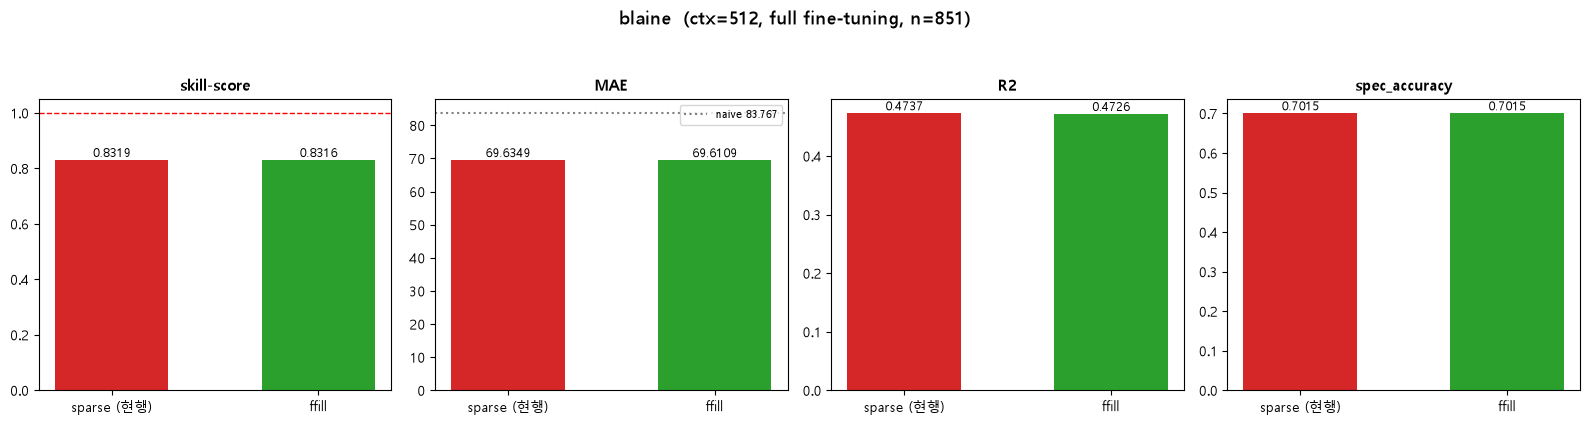

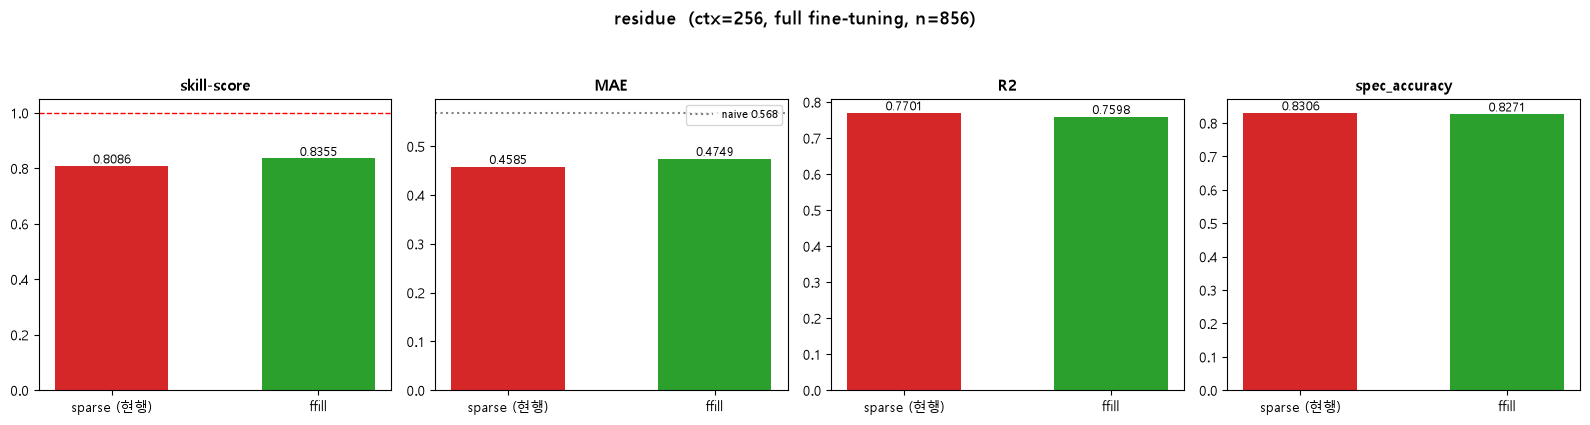

In [5]:
def plot_target(t):
    d = {arm: res[(t, arm)] for arm in ARMS}
    m = {arm: compute_metrics(d[arm], cfg.SPEC_RANGES[t]) for arm in ARMS}
    sk = {arm: normalized_skill_score(d[arm]) for arm in ARMS}
    nmae = float(np.abs(d['sparse']['actual'] - d['sparse']['naive_pred']).mean())
    panels = [('skill-score', sk, None), ('MAE', {k: m[k]['MAE'] for k in ARMS}, nmae),
              ('R2', {k: m[k]['R2'] for k in ARMS}, None),
              ('spec_accuracy', {k: m[k]['spec_accuracy'] for k in ARMS}, None)]
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(f'{t}  (ctx={CTX[t]}, full fine-tuning, n={len(d["sparse"])})',
                 fontsize=13, fontweight='bold', y=1.05)
    for ax, (name, vals, naive) in zip(axes, panels):
        xs = np.arange(len(ARMS))
        bars = ax.bar(xs, [vals[a] for a in ARMS], color=[COLOR[a] for a in ARMS], width=0.55)
        for bb, a in zip(bars, ARMS):
            ax.text(bb.get_x() + bb.get_width() / 2, bb.get_height(), f'{vals[a]:.4f}',
                    ha='center', va='bottom', fontsize=9)
        if naive is not None:
            ax.axhline(naive, color='grey', ls=':', label=f'naive {naive:.3f}'); ax.legend(fontsize=8)
        if name == 'skill-score':
            ax.axhline(1.0, color='red', ls='--', lw=1)
        ax.set_xticks(xs); ax.set_xticklabels([LABEL[a] for a in ARMS])
        ax.set_title(name, fontsize=11, fontweight='bold')
    plt.tight_layout(); plt.show()

for t in cfg.TARGET_COLS:
    plot_target(t)


## 5. 결론

In [6]:
for t in cfg.TARGET_COLS:
    a, b = res[(t, 'sparse')], res[(t, 'ffill')]
    sa, sb = normalized_skill_score(a), normalized_skill_score(b)
    ma = compute_metrics(a, cfg.SPEC_RANGES[t])['MAE']
    mb = compute_metrics(b, cfg.SPEC_RANGES[t])['MAE']
    d = sb - sa
    verdict = 'ffill 우세' if d < -0.004 else ('sparse 우세' if d > 0.004 else '차이 노이즈 수준')
    print(f'{t:8s}: sparse skill={sa:.4f} MAE={ma:.4f}  |  ffill skill={sb:.4f} MAE={mb:.4f}  -> {verdict} (Δskill={d:+.4f})')


blaine  : sparse skill=0.8319 MAE=69.6349  |  ffill skill=0.8316 MAE=69.6109  -> 차이 노이즈 수준 (Δskill=-0.0002)
residue : sparse skill=0.8086 MAE=0.4585  |  ffill skill=0.8355 MAE=0.4749  -> sparse 우세 (Δskill=+0.0269)


<!-- 결론 텍스트는 EXPERIMENT_LOG.md 참조 -->